<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1>Fashion-MNIST Project </h1>


<h2>Table of Contents</h2>


<p>In this project, you will classify  Fashion-MNIST dataset using convolutional neural networks.</p>
<ul>
  
<ul>
<li><a href="#Preparation">Preparation</a></li>
<li><a href="#Q1">Questions 1: Create a Dataset Class</a></li>
<li><a href="#Q2">Define Softmax, Criterion function, Optimizer and Train the Model</a></li>

</ul>
 

</ul>

<p>Estimated Time Needed: <b>30 min</b></p>
<hr>


<a name="Preparation"><h2 id="Preparation" >Preparation</h2></a>


Download the datasets you needed for this lab.


The following are the PyTorch modules you are going to need


In [ ]:
%%time
%pip install pandas numpy matplotlib
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu

In [ ]:
# !pip install torch
# !pip install torchvision
# !pip install matplotlib

In [1]:
# PyTorch Modules you need for this lab

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
import torch 
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
torch.manual_seed(0)

Import Non-PyTorch Modules 


In [3]:
# Other non-PyTorch Modules

from matplotlib.pyplot import imshow
import matplotlib.pylab as plt

from PIL import Image

In [5]:
def show_data(data_sample):
    plt.imshow(data_sample[0].numpy().reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    plt.title('y = '+ str(data_sample[1]))

<hr>


<hr>


<a name="Q1"><h2 id="Q1">Questions 1: Create a Dataset Class</h2></a>


In this section, you will load a Dataset object, but first you must transform the dataset. Use the <code>Compose</code> function to perform the following transforms:. 
<ol>
    <li>Use the transforms object to<code> Resize </code> to resize the image.</li>
    <li>Use the transforms object to<code> ToTensor </code> to convert the image to a tensor.</li>
</ol>

You will then take a screen shot of your validation data.


Use the Compose function to compose the transforms


100%|██████████| 26421880/26421880 [00:13<00:00, 1903425.69it/s] 


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 895021.38it/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:01<00:00, 3687291.44it/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 14462342.26it/s]


Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw

Validation batch images shape: torch.Size([64, 1, 16, 16])
Validation batch labels shape: torch.Size([64])


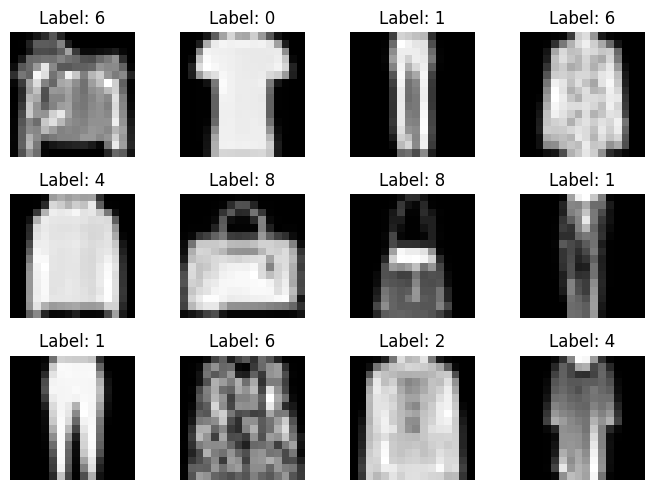

In [6]:
# ------------------------------------------------------------
# Fashion-MNIST: build image transforms, load dataset + split,
# and (optionally) visualize a few validation images.
# ------------------------------------------------------------

import torch
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1) Define the target size for resizing (per the screenshot hint)
IMAGE_SIZE = 16

# 2) Compose the required transforms:
#    - Resize: makes every image IMAGE_SIZE x IMAGE_SIZE
#    - ToTensor: converts PIL image -> torch.Tensor in [0, 1]
composed = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# 3) Load Fashion-MNIST using the composed transform
#    Fashion-MNIST images are grayscale (1 channel), labels are 0..9
trainval_data = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=composed
)

test_data = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=composed
)

# 4) Split train into train + validation
val_ratio = 0.2
val_size = int(len(trainval_data) * val_ratio)
train_size = len(trainval_data) - val_size

# For reproducibility (optional): fix the RNG seed for the split...I'm using 42 as a nod to The Hitchhiker's Guide to the Galaxy!
g = torch.Generator().manual_seed(42)
train_data, val_data = random_split(trainval_data, [train_size, val_size], generator=g)

# 5) Create DataLoaders (tune batch_size as you like)
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

# ------------------------------------------------------------
# OPTIONAL: "Take a screenshot of your validation data"
# This prints shapes and shows a small grid of validation images.
# ------------------------------------------------------------

# Grab one batch from the validation loader
images, labels = next(iter(val_loader))

print("Validation batch images shape:", images.shape)  # e.g., [64, 1, 16, 16]
print("Validation batch labels shape:", labels.shape)  # e.g., [64]

# Display the first 12 images in the batch
num_show = 12
fig, axes = plt.subplots(3, 4, figsize=(7, 5))
axes = axes.flatten()

for i in range(num_show):
    # images[i] is [1, 16, 16] (C,H,W). Squeeze channel for plotting.
    axes[i].imshow(images[i].squeeze(0), cmap="gray")
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


<hr>


Create two dataset objects for the Fashion MNIST  dataset. One for training data called <code> dataset_train </code> and one for validation data <code>dataset_val</code>. You will be asked to take a screenshot of several samples.


<b>Hint:</b>
<code>dsets.FashionMNIST(root= '.fashion/data', train=???, transform=composed,  download=True)</code>


In [7]:
# ------------------------------------------------------------
# Create training and validation datasets for Fashion-MNIST
# ------------------------------------------------------------

from torchvision import datasets
from torch.utils.data import random_split

# Load the full *training* portion of Fashion-MNIST
# (this contains both train + validation samples initially)
dataset_full = datasets.FashionMNIST(
    root="./data",        # where the dataset is stored/downloaded
    train=True,           # use the training split (60,000 images)
    download=True,        # download if not already present
    transform=composed   # image transforms (Resize + ToTensor)
)

# Define how much data to reserve for validation
val_ratio = 0.2                          # 20% for validation
val_size = int(len(dataset_full) * val_ratio)
train_size = len(dataset_full) - val_size

# Split the dataset into training and validation subsets
# A fixed seed ensures the split is reproducible
dataset_train, dataset_val = random_split(
    dataset_full,
    [train_size, val_size]
)



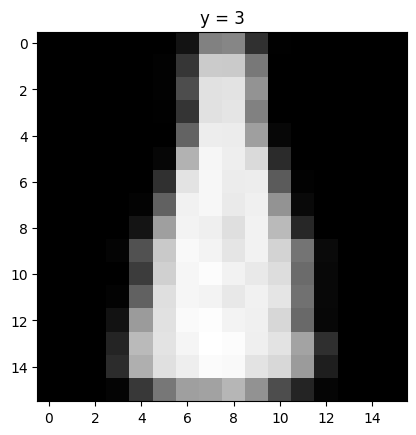

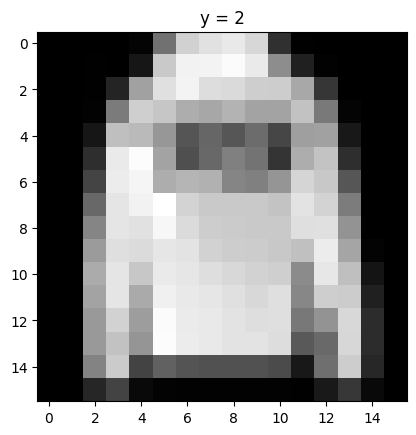

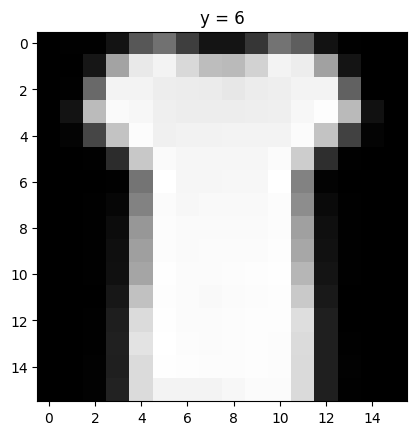

In [8]:
for n,data_sample in enumerate(dataset_val):

    show_data(data_sample)
    plt.show()
    if n==2:
        break 

<a name="Q2"><h2 id="Q2">Questions 2</h2></a>
Create a Convolutional Neural Network class using ONE of the following constructors.  Train the network using the provided code then provide a screenshot of your training cost and accuracy with your validation data.


Constructor  using Batch Norm 


In [ ]:
class CNN_batch(nn.Module):
    
    # Constructor
    def __init__(self, out_1=16, out_2=32,number_of_classes=10):
        super(CNN_batch, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.conv1_bn = nn.BatchNorm2d(out_1)

        self.maxpool1=nn.MaxPool2d(kernel_size=2)
        
        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.conv2_bn = nn.BatchNorm2d(out_2)

        self.maxpool2=nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(out_2 * 4 * 4, number_of_classes)
        self.bn_fc1 = nn.BatchNorm1d(10)
    
    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x=self.conv1_bn(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x=self.conv2_bn(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x=self.bn_fc1(x)
        return x

Constructor  for regular Convolutional Neural Network


In [11]:
class CNN(nn.Module):
    
    # Constructor
    def __init__(self, out_1=16, out_2=32,number_of_classes=10):
        super(CNN, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.maxpool1=nn.MaxPool2d(kernel_size=2)

        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.maxpool2=nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(out_2 * 4 * 4, number_of_classes)
    
    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

train loader  and validation loader 


In [12]:
train_loader = torch.utils.data.DataLoader(dataset=dataset_train, batch_size=100 )
test_loader = torch.utils.data.DataLoader(dataset=dataset_val, batch_size=100 )

Convolutional Neural Network object 


In [13]:
model = CNN(out_1=16, out_2=32,number_of_classes=10)
#model =CNN_batch(out_1=16, out_2=32,number_of_classes=10)

Create the objects for the criterion and the optimizer named <code>criterion</code> and <code>optimizer</code>. Make the optimizer use SGD with a learning rate of 0.1 and the optimizer use Cross Entropy Loss


In [14]:
import torch.nn as nn
import torch.optim as optim

# Loss function:
# CrossEntropyLoss is the standard choice for multi-class classification
# (it expects raw logits from the model, not softmax outputs)
criterion = nn.CrossEntropyLoss()

# Optimizer:
# Stochastic Gradient Descent updates model parameters using gradients
# learning rate = 0.1 (aggressive, but fine for this small CNN)
optimizer = optim.SGD(model.parameters(), lr=0.1)


Code used to train the model 


In [15]:
import time
start_time = time.time()

cost_list=[]
accuracy_list=[]
N_test=len(dataset_val)
n_epochs=5
for epoch in range(n_epochs):
    cost=0
    model.train()
    for x, y in train_loader:
        optimizer.zero_grad()
        z = model(x)
        loss = criterion(z, y)
        loss.backward()
        optimizer.step()
        cost+=loss.item()
    correct=0
    #perform a prediction on the validation  data 
    model.eval()
    for x_test, y_test in test_loader:
        z = model(x_test)
        _, yhat = torch.max(z.data, 1)
        correct += (yhat == y_test).sum().item()
    accuracy = correct / N_test
    accuracy_list.append(accuracy)
    cost_list.append(cost)
    

You will use the following to plot the Cost and accuracy for each epoch for the training and testing data, respectively. 


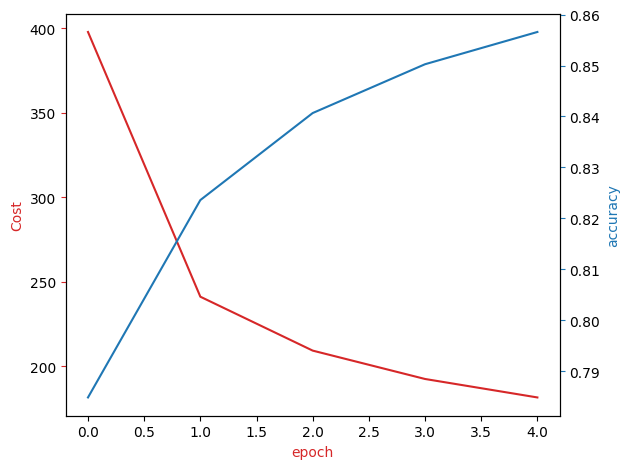

In [16]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.plot(cost_list, color=color)
ax1.set_xlabel('epoch', color=color)
ax1.set_ylabel('Cost', color=color)
ax1.tick_params(axis='y', color=color)
    
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color) 
ax2.set_xlabel('epoch', color=color)
ax2.plot( accuracy_list, color=color)
ax2.tick_params(axis='y', color=color)
fig.tight_layout()

dataset: https://github.com/zalandoresearch/fashion-mnist


<h2>About the Authors:</h2> 

<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


Other contributors: <a href="https://www.linkedin.com/in/michelleccarey/">Michelle Carey</a>, <a href="https://www.linkedin.com/in/jiahui-mavis-zhou-a4537814a">Mavis Zhou</a> 


<hr>


## <h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
